In [1]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Đã kết nối Google Drive')

Mounted at /content/drive
✅ Đã kết nối Google Drive


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print(f'✅ TensorFlow: {tf.__version__}')
print(f'✅ GPU: {tf.config.list_physical_devices("GPU")}')

✅ TensorFlow: 2.20.0
✅ GPU: []


In [3]:
BASE      = '/content/drive/MyDrive/DataDeeplearning/DataSet'
TRAIN_DIR = os.path.join(BASE, 'Train')
VAL_DIR   = os.path.join(BASE, 'Val')
MODEL_DIR = '/content/drive/MyDrive/DataDeeplearning/Models'
os.makedirs(MODEL_DIR, exist_ok=True)

print('📂 Cấu trúc Dataset:')
total_train = total_val = 0
for split, path in [('Train', TRAIN_DIR), ('Val', VAL_DIR)]:
    print(f'\n  {split}/')
    for cls in sorted(os.listdir(path)):
        cls_path = os.path.join(path, cls)
        if os.path.isdir(cls_path):
            n = len(os.listdir(cls_path))
            print(f'    {cls}: {n} ảnh')
            if split == 'Train': total_train += n
            else:                total_val   += n

print(f'\n📊 Tổng: Train={total_train} | Val={total_val}')
if total_train < 400:
    print('⚠️  Nên thêm ảnh để kết quả tốt hơn')

📂 Cấu trúc Dataset:

  Train/
    Long_Nail: 104 ảnh
    Painted_Nail: 93 ảnh
    Short_Nail: 86 ảnh

  Val/
    Long_Nail: 20 ảnh
    Painted_Nail: 25 ảnh
    Short_Nail: 28 ảnh

📊 Tổng: Train=283 | Val=73
⚠️  Nên thêm ảnh để kết quả tốt hơn


In [5]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],
    fill_mode='nearest'
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)
val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

CLASS_NAMES = {v: k for k, v in train_generator.class_indices.items()}
NUM_CLASSES = len(CLASS_NAMES)
print(f'✅ Train: {train_generator.samples} ảnh | Val: {val_generator.samples} ảnh')
print(f'📂 Classes: {train_generator.class_indices}')

Found 283 images belonging to 3 classes.
Found 73 images belonging to 3 classes.
✅ Train: 283 ảnh | Val: 73 ảnh
📂 Classes: {'Long_Nail': 0, 'Painted_Nail': 1, 'Short_Nail': 2}


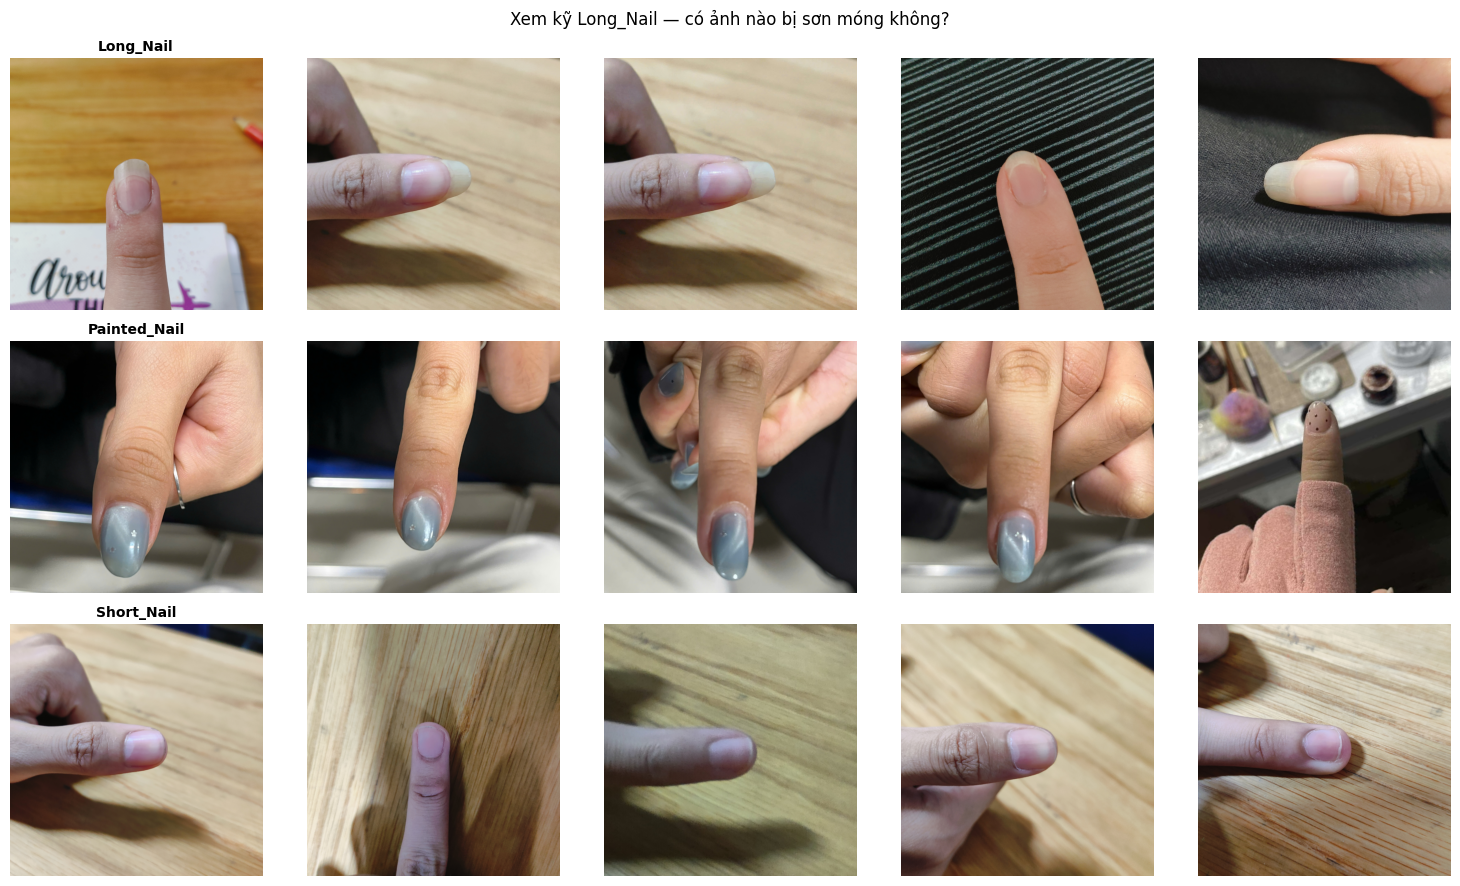

In [ ]:
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for cls_idx, cls_name in CLASS_NAMES.items():
    cls_dir = os.path.join(TRAIN_DIR, cls_name)
    files   = os.listdir(cls_dir)[:5]
    for col, fname in enumerate(files):
        img = plt.imread(os.path.join(cls_dir, fname))
        axes[cls_idx][col].imshow(img)
        axes[cls_idx][col].axis('off')
        if col == 0:
            axes[cls_idx][col].set_title(cls_name, fontsize=10, fontweight='bold')
plt.suptitle('Xem kỹ Long_Nail — có ảnh nào bị sơn móng không?', fontsize=12)
plt.tight_layout()
plt.show()

In [6]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu',
          kernel_regularizer=regularizers.l2(0.001))(x)
x = Dropout(0.4)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print(f'✅ Model mới sẵn sàng')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Model mới sẵn sàng


In [7]:
checkpoint_path = os.path.join(MODEL_DIR, 'best_model.keras')

callbacks_p1 = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        save_best_only=True,
        monitor='val_loss', mode='min', verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=8,
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=1e-6, verbose=1
    )
]

print('🚀 Train Phase 1 — Feature Extraction...')
history1 = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=callbacks_p1
)

🚀 Train Phase 1 — Feature Extraction...
Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4248 - loss: 1.6381
Epoch 1: val_loss improved from None to 0.78695, saving model to /content/drive/MyDrive/DataDeeplearning/Models/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DataDeeplearning/Models/best_model.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 112s 6s/step - accuracy: 0.4947 - loss: 1.4452 - val_accuracy: 0.7671 - val_loss: 0.7869 - learning_rate: 0.0010
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 952ms/step - accuracy: 0.6599 - loss: 0.9930
Epoch 2: val_loss improved from 0.78695 to 0.59917, saving model to /content/drive/MyDrive/DataDeeplearning/Models/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/DataDeeplearning/Models/best_model.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.7138 - loss: 0.9463 - val_accuracy: 0.8219 - val_loss: 0.5992 - learning_rate: 0.0010
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 980ms/step -

In [ ]:
from tensorflow.keras.models import load_model

print('📥 Load best model từ Phase 1...')
model = load_model(checkpoint_path)

# Layer MobileNetV2 chạy từ index 1 đến 153 (out_relu)
# Đóng băng từ đầu đến layer 123 (block_13), mở 30 layer cuối (124-153)
FREEZE_UNTIL = 124

for i, layer in enumerate(model.layers):
    if i < FREEZE_UNTIL:
        layer.trainable = False
    else:
        layer.trainable = True

trainable_count = sum(1 for l in model.layers if l.trainable)
print(f'✅ Trainable layers: {trainable_count} / {len(model.layers)}')

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

finetune_path = os.path.join(MODEL_DIR, 'best_model_finetuned.keras')

callbacks_p2 = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=finetune_path,
        save_best_only=True,
        monitor='val_loss', mode='min', verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=7,
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=1e-7, verbose=1
    )
]

print('🚀 Fine-tuning Phase 2...')
history2 = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=callbacks_p2
)
print(f'\n✅ Đã lưu: {finetune_path}')

📥 Load best model từ Phase 1...
✅ Trainable layers: 35 / 159
🚀 Fine-tuning Phase 2...
Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5735 - loss: 1.5920
Epoch 1: val_loss improved from None to 0.91365, saving model to /content/drive/MyDrive/DataDeeplearning/Models/best_model_finetuned.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DataDeeplearning/Models/best_model_finetuned.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.5783 - loss: 1.5443 - val_accuracy: 0.7647 - val_loss: 0.9137 - learning_rate: 1.0000e-05
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5759 - loss: 1.4091
Epoch 2: val_loss did not improve from 0.91365
20/20 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.5559 - loss: 1.4455 - val_accuracy: 0.7294 - val_loss: 0.9357 - learning_rate: 1.0000e-05
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5911 - loss: 1.4388
Epoch 3: val_loss did not improve from 0.91365
20/20 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/ste

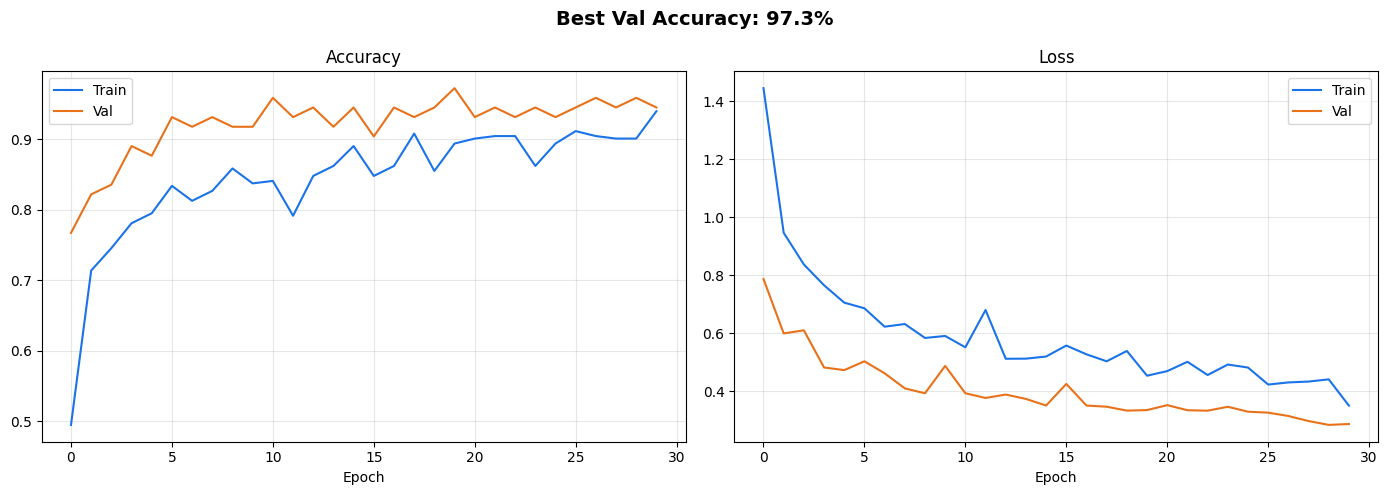

📊 Best Val Accuracy : 97.3%
   Train Accuracy    : 94.0%
   Khoảng cách       : -3.3%


In [8]:
# Cell 9 — Biểu đồ kết quả (chỉ dùng Phase 1)
acc      = history1.history['accuracy']
val_acc  = history1.history['val_accuracy']
loss     = history1.history['loss']
val_loss = history1.history['val_loss']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for ax, tr, vl, title in [
    (ax1, acc,  val_acc,  'Accuracy'),
    (ax2, loss, val_loss, 'Loss')
]:
    ax.plot(tr, label='Train', color='#1a73e8')
    ax.plot(vl, label='Val',   color='#e8711a')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

best_val = max(val_acc)
plt.suptitle(f'Best Val Accuracy: {best_val:.1%}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'training_chart.png'), dpi=150)
plt.show()
print(f'📊 Best Val Accuracy : {best_val:.1%}')
print(f'   Train Accuracy    : {max(acc):.1%}')
print(f'   Khoảng cách       : {max(acc) - best_val:.1%}')

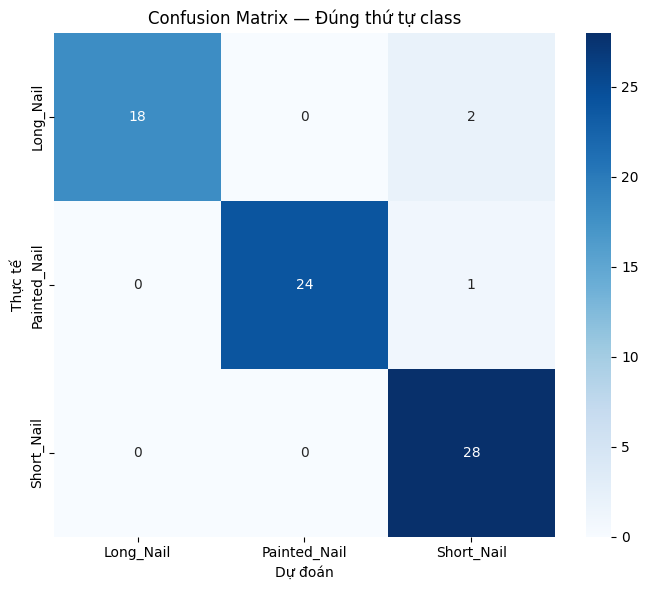

              precision    recall  f1-score   support

   Long_Nail       1.00      0.90      0.95        20
Painted_Nail       1.00      0.96      0.98        25
  Short_Nail       0.90      1.00      0.95        28

    accuracy                           0.96        73
   macro avg       0.97      0.95      0.96        73
weighted avg       0.96      0.96      0.96        73



In [9]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image as keras_image

model_eval = load_model(checkpoint_path)

# Dự đoán từng ảnh thủ công — tránh lỗi shuffle/reset
y_true, y_pred = [], []

for cls_idx, cls_name in CLASS_NAMES.items():
    cls_dir = os.path.join(VAL_DIR, cls_name)
    for fname in os.listdir(cls_dir):
        fpath = os.path.join(cls_dir, fname)
        try:
            img = keras_image.load_img(fpath, target_size=IMG_SIZE)
            x   = keras_image.img_to_array(img) / 255.0
            x   = np.expand_dims(x, axis=0)
            pred = model_eval.predict(x, verbose=0)[0]
            y_true.append(cls_idx)
            y_pred.append(np.argmax(pred))
        except:
            pass

labels = [CLASS_NAMES[i] for i in range(NUM_CLASSES)]
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.title('Confusion Matrix — Đúng thứ tự class')
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=labels))

✅ Load model xong


Saving h3.png to h3.png


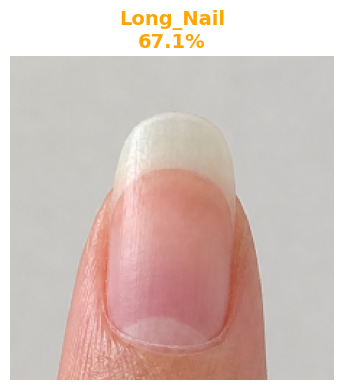

  Long_Nail       67.1%  ████████████████████
  Painted_Nail    23.8%  ███████
  Short_Nail      9.1%  ██


In [13]:
from google.colab import files
from tensorflow.keras.preprocessing import image as keras_image

checkpoint_path = os.path.join(MODEL_DIR, 'best_model.keras')
model_eval = load_model(checkpoint_path)
print('✅ Load model xong')

# Upload và test ảnh
uploaded = files.upload()
for fname, fdata in uploaded.items():
    with open(fname, 'wb') as f:
        f.write(fdata)

    img  = keras_image.load_img(fname, target_size=IMG_SIZE)
    x    = keras_image.img_to_array(img) / 255.0
    x    = np.expand_dims(x, axis=0)
    pred = model_eval.predict(x, verbose=0)[0]

    ket_qua = CLASS_NAMES[np.argmax(pred)]
    do_tin  = pred[np.argmax(pred)]

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis('off')
    mau = 'green' if do_tin > 0.7 else 'orange'
    plt.title(f'{ket_qua}\n{do_tin:.1%}', color=mau, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    for i, p in enumerate(pred):
        print(f'  {CLASS_NAMES[i]:15s} {p:.1%}  {"█" * int(p*30)}')

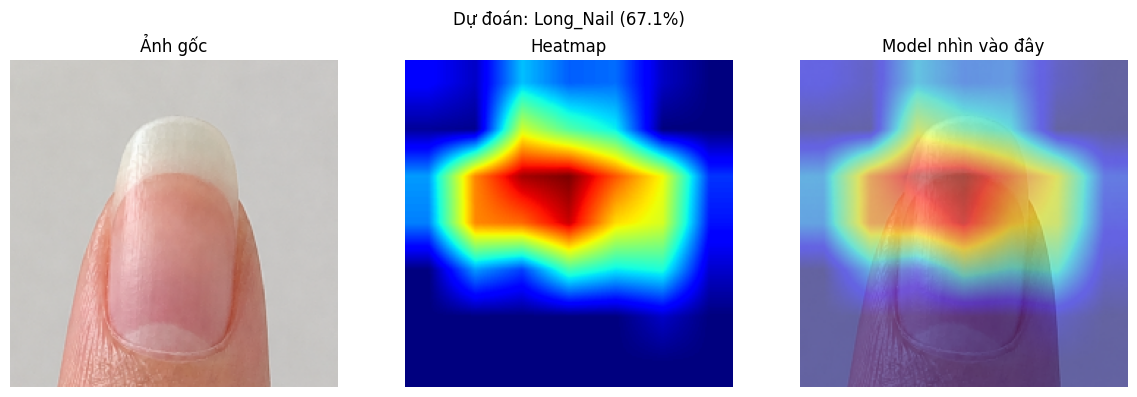

In [14]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tensorflow.keras.preprocessing import image as keras_image

def grad_cam(model, img_path, layer_name='Conv_1'):
    img  = keras_image.load_img(img_path, target_size=IMG_SIZE)
    x    = keras_image.img_to_array(img) / 255.0
    x    = np.expand_dims(x, axis=0)

    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(x)
        pred_idx = tf.argmax(preds[0])
        loss = preds[:, pred_idx]

    grads    = tape.gradient(loss, conv_out)
    pooled   = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out = conv_out[0]
    heatmap  = conv_out @ pooled[..., tf.newaxis]
    heatmap  = tf.squeeze(heatmap).numpy()
    heatmap  = np.maximum(heatmap, 0)
    heatmap  = heatmap / (heatmap.max() + 1e-8)

    # Overlay lên ảnh gốc
    img_arr  = keras_image.img_to_array(img).astype('uint8')
    heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], IMG_SIZE).numpy().squeeze()
    colored  = cm.jet(heatmap_resized)[:, :, :3] * 255
    overlay  = (img_arr * 0.5 + colored * 0.5).astype('uint8')

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img);          axes[0].set_title('Ảnh gốc');     axes[0].axis('off')
    axes[1].imshow(heatmap_resized, cmap='jet'); axes[1].set_title('Heatmap'); axes[1].axis('off')
    axes[2].imshow(overlay);      axes[2].set_title('Model nhìn vào đây'); axes[2].axis('off')

    pred = model.predict(x, verbose=0)[0]
    plt.suptitle(f'Dự đoán: {CLASS_NAMES[np.argmax(pred)]} ({pred[np.argmax(pred)]:.1%})', fontsize=12)
    plt.tight_layout()
    plt.show()

# Dùng ảnh vừa upload
grad_cam(model_eval, fname)